# Kylie King’s DSAN 6750 GIS project

Kylie King (Georgetown University)

## Abstract

The purpose of this project is to investigate whether Ireland is caring for its historic fairy habitats. Because fairies are notorious for obstructing data collection and interfering with computer calculations, there is very little data available on fairy habitats and their preservation. This is a two-part project, where we first determine where fairies prefer to live, and then assess whether their preferred habitat is flourishing. Data collected (with much sacrifice) on the location of fairy barrows (homes) will be converted into a density layer to determine where fairy barrows are most densely clustered. Next, land cover data from 1990 will be compared to the barrow density to determine which habitat fairies prefer. Finally, land cover data from 2018 will be compared to the 1990 dataset, to produce a change matrix, and identify whether Irish fairy habitat remains intact.

## Literature Review

mostly talking about stories about fairies, for funsies

# Data Collection and Preparation

Barrows data, two land cover datas, natural earth data country layer

In [ ]:
library(tidyverse) |> suppressPackageStartupMessages()
library(sf) |> suppressPackageStartupMessages()
library(mapview) |> suppressPackageStartupMessages()
library(spatstat) |> suppressPackageStartupMessages()
library(stars) |> suppressPackageStartupMessages()
library(rnaturalearth) |> suppressPackageStartupMessages()
library(terra) |> suppressPackageStartupMessages()
library(tidyterra) |> suppressPackageStartupMessages()
set.seed(6805)

In [ ]:
barrows_df <- read_csv('data/raw/barrows.csv')

New names:
• `` -> `...11`
• `` -> `...12`
• `` -> `...13`
• `` -> `...14`
• `` -> `...15`

e.g.:
  dat <- vroom(...)
  problems(dat)

Rows: 3832 Columns: 15
── Column specification ────────────────────────────────────────────────────────
Delimiter: ","
chr (9): townland, county, smrs, entity_id, class_code, monument_type, web_n...
dbl (3): objectid, latitude, longitude
lgl (3): ...11, ...12, ...15

ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types or set `show_col_types = FALSE` to quiet this message.

Simple feature collection with 6 features and 5 fields
Geometry type: POINT
Dimension:     XY
Bounding box:  xmin: -9.616146 ymin: 52.27382 xmax: -9.288232 ymax: 54.21839
Geodetic CRS:  WGS 84
# A tibble: 6 × 6
  townland               county smrs  class_code type              geometry
  <chr>                  <chr>  <chr> <chr>      <chr>          <POINT [°]>
1 BALLINCOLLIG           KERRY  KE03… BOBA       barr… (-9.616146 52.29946)
2 CARRIGNAFEELA (Trugha… KERRY  KE03… BOBA       barr… (-9.602639 52.27382)
3 CRAGGYCORRADAN EAST    CLARE  CL00… BOBA       barr… (-9.335978 53.04122)
4 CARROWKEEL (Tirawley … MAYO   MA01… BOBA       barr… (-9.312925 54.21839)
5 BALLYALLA              CLARE  CL01… BOBA       barr…  (-9.293532 52.9808)
6 CARROWKEEL (Corcomroe… CLARE  CL01… BOBA       barr… (-9.288232 52.98236)

In [ ]:
ireland <- ne_countries(country = "ireland", scale="large")
mapview(ireland)

ok so, instead of the intensity function of population which is divided into low, med, and high density, I have the raster dataset which is split into ~5 habitat types

## Hypotheses

Hypothesis 1: Fairies mainly live in forested areas Hypothesis 2: In accordance with global trends, fairy habitat is declining.

## Where Do Fairies Live?

probably forests I think

# Viewing Window Construction

In [ ]:
ireland_sfc <- ireland |> st_convex_hull() #unsure if we will need this yet, or if the base shapefile will work for all the points

ireland <- ireland |> sf::st_transform(2157)

ireland_sfc <- ireland_sfc |> sf::st_transform(2157) #Irish Transverse Mercator
mapview(ireland_sfc)

# Intensity Layer Construction

wahoooo actually do i need this? Gonna read in the raster first to see what’s up

# Land Cover Analysis

this is where I have to do interesting things with a raster, not sure how to do that yet. Will definitely have to reclassify to make sure the two land covers match

In [ ]:
temp_dir <- tempdir() #temporary directory for working
zip_file_path <- "data/raw/Rasters.zip" #path to raster
unzip(zipfile = zip_file_path, exdir = temp_dir) #unzipping into temp directory

# 1990 dataset
tiff_file_path_1990 <- file.path(temp_dir, "Rasters/U2000_CLC1990_V2020_20u1/U2000_CLC1990_V2020_20u1/U2000_CLC1990_V2020_20u1.tif")
lc_1990 <- rast(tiff_file_path_1990)

# 2018 dataset
tiff_file_path_2018 <- file.path(temp_dir, "Rasters/U2018_CLC2018_V2020_20u1/U2018_CLC2018_V2020_20u1/U2018_CLC2018_V2020_20u1.tif")
lc_2018 <- rast(tiff_file_path_2018)

ℹ Consider using `geom_tile()` instead.
Raster pixels are placed at uneven horizontal intervals and will be shifted
ℹ Consider using `geom_tile()` instead.

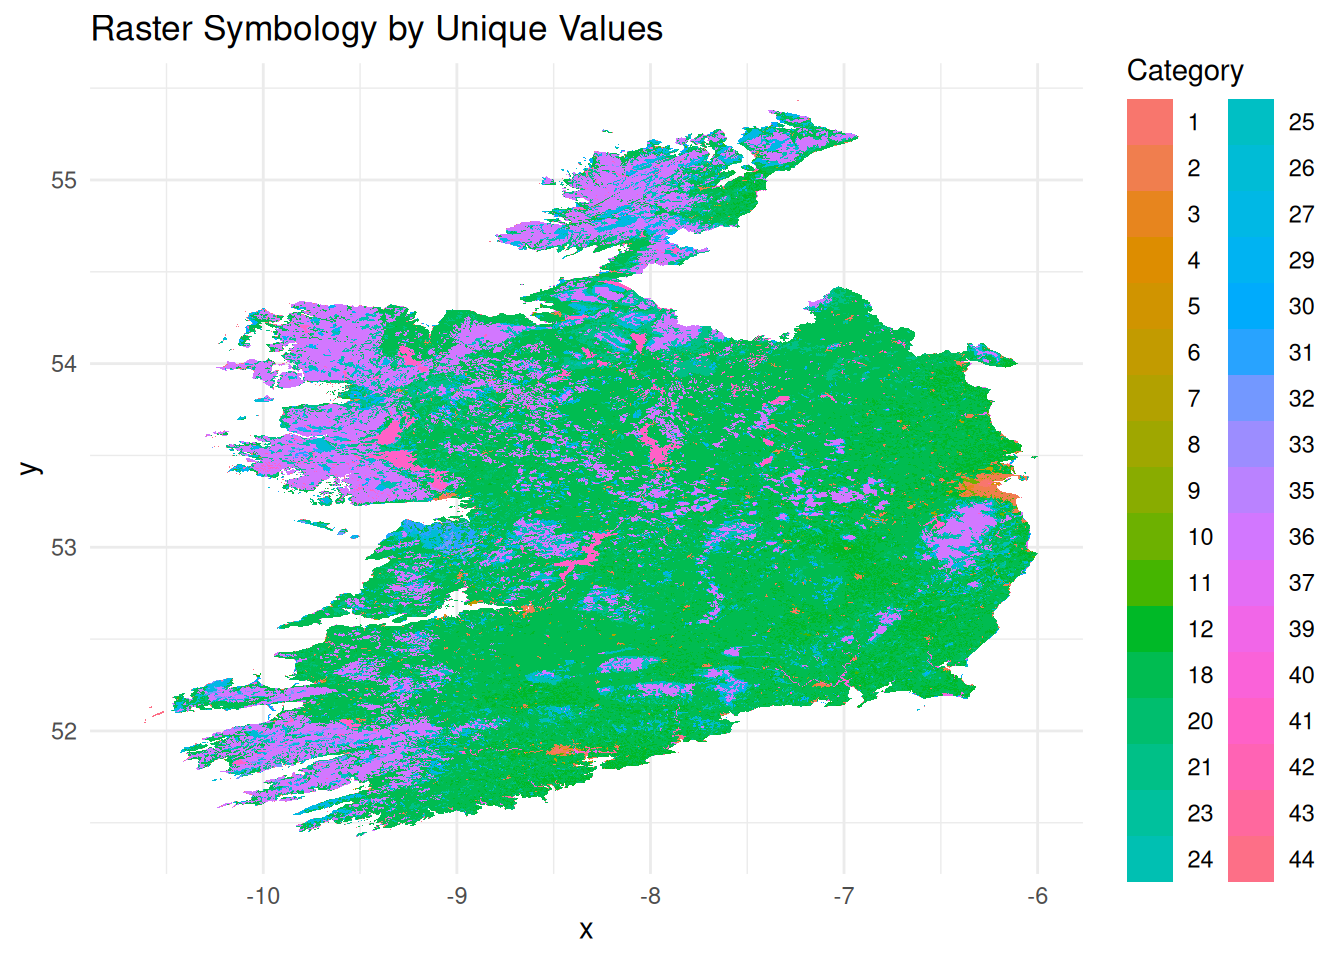

In [ ]:
# This works!!
# Convert the raster to a data frame for ggplot2
lc_df_test <- as.data.frame(lc_1990, xy=TRUE) |>
  rename(value = U2000_CLC1990_V2020_20u1) # Rename the value column

# Ensure the 'value' column is treated as a factor for discrete colors
lc_df_test$value <- factor(lc_df_test$value)

# Plot using ggplot2
ggplot(data = lc_df_test, aes(x = x, y = y, fill = value)) +
  geom_raster() +
  labs(title = "Raster Symbology by Unique Values", fill = "Category") +
  theme_minimal()

In [ ]:
rclmat <- matrix(c(1, 11, 1,
                   11.999, 22, 2,
                   22.999, 25, 3,
                   25.999, 27, 4,
                   27.999, 29, 3,
                   29.999, 34, 5,
                   34.999, 39, 6,
                   39.999, 44, 7
                   ), ncol=3, byrow=TRUE)

rc_test_1990 <- classify(lc_1990, rclmat, include.lowest=TRUE)

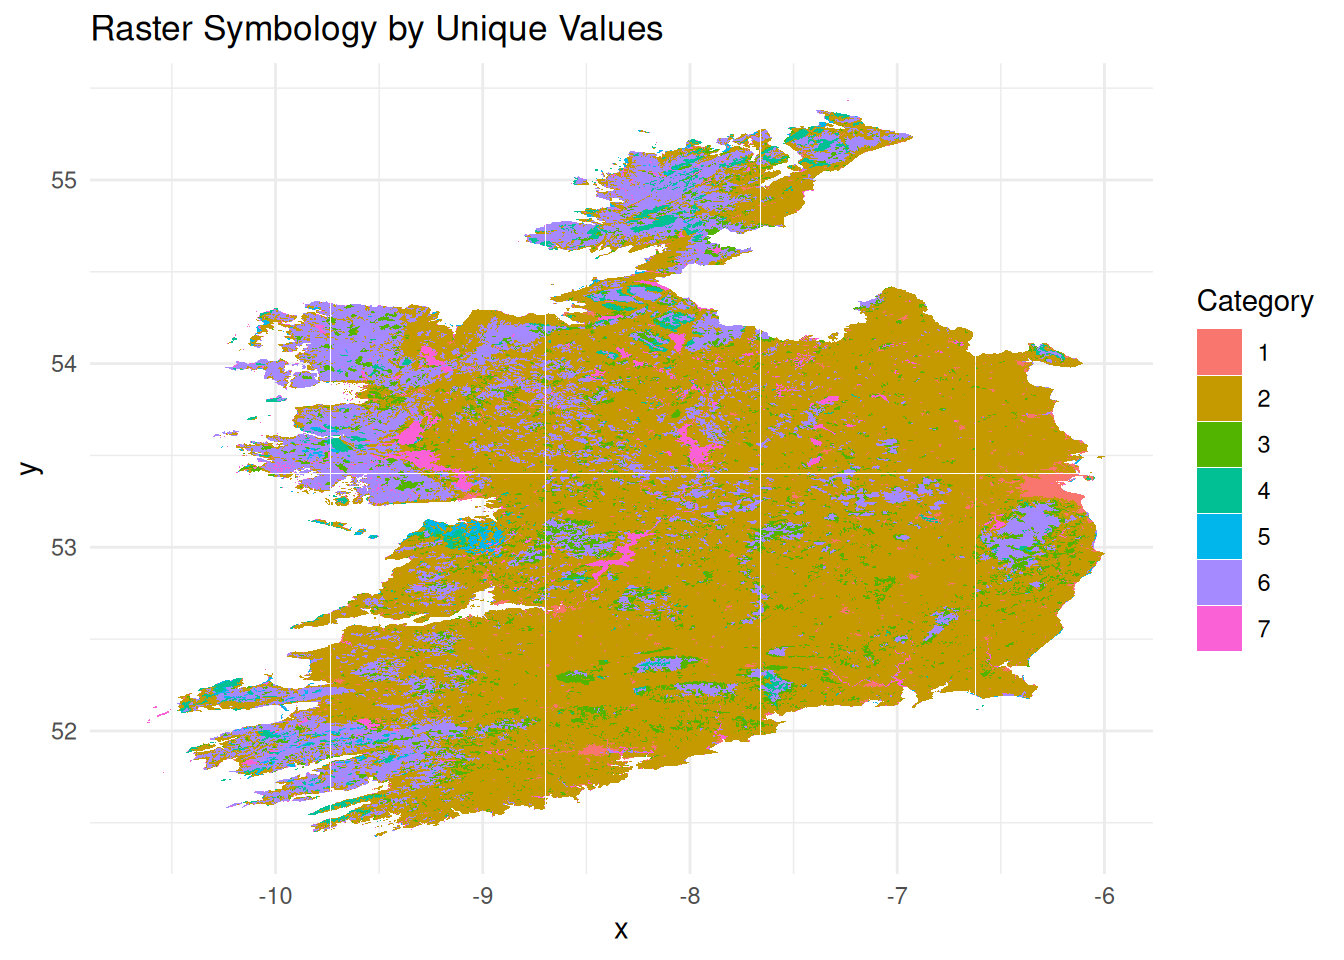

In [ ]:
rc_test_1990_df <- as.data.frame(rc_test_1990, xy=TRUE) |>
  rename(value = U2000_CLC1990_V2020_20u1) # Rename the value column

# Ensure the 'value' column is treated as a factor for discrete colors
rc_test_1990_df$value <- factor(rc_test_1990_df$value)

# Plot using ggplot2
ggplot(data = rc_test_1990_df, aes(x = x, y = y, fill = value)) +
  geom_tile() +
  labs(title = "Raster Symbology by Unique Values", fill = "Category") +
  theme_minimal()

## Fairy Habitat Preservation

small little paragraph about what we have to do, also maybe prepping the land cover

# Change Matrix

no idea how do to this, wheeeeeeee

## Discussion and Findings

the irish people are probably in danger because i bet fairy habitat has declined